# TVR Benchmark Analysis CLIP4Clip & GRAM

End-to-end evaluation on the **MammAlps test split**.

**Pipeline for each model:**
1. Load the test/train similarity matrix produced by the evaluation script
0. Validate on the train split to calibrate per-query thresholds 
2. Apply per-query min-max normalisation (same as in validation)
3. Apply the per-query threshold calibrated on the train split
4. Compute **F1 (macro-avg)**, **mIoU**, and **mAP** per query → aggregate

| Symbol | Meaning |
|---|---|
| mIoU | mean Intersection-over-Union (predicted set ∩ GT) / (predicted set ∪ GT), averaged across queries |
| F1 (macro-avg) | unweighted mean of per-query binary F1 |
| mAP | mean Average Precision area under the per-query precision–recall curve |

## 1. Import Libraries and Configure Paths

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    mean_average_precision_score,
    F1_score_from_sim,
    IoU_from_sim,
    IoU_q
)

%load_ext autoreload
%autoreload 2
base_path="../zero_shot"

# CLIP4Clip
clip_path = Path(base_path) / "CLIP4Clip"
CLIP_SIM_TEST   = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/CLIP4Clip/test/similarity_matrix.csv"
CLIP_SIM_TRAIN  = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/CLIP4Clip/train/similarity_matrix.csv"
CLIP_GT_TEST    = clip_path / "dataset/test/ground_truth.json"
CLIP_GT_TRAIN   = clip_path / "dataset/train/ground_truth.json"

# SigLIP4Clip
clip_path = Path(base_path) / "CLIP4Clip"
SigLIP_SIM_TEST   = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/SigLIP4Clip/test/similarity_matrix.csv"
SigLIP_SIM_TRAIN  = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/SigLIP4Clip/train/similarity_matrix.csv"
SigLIP_GT_TEST    = clip_path / "dataset/test/ground_truth.json"
SigLIP_GT_TRAIN   = clip_path / "dataset/train/ground_truth.json"

# GRAM
gram_path = Path(base_path) / "GRAM"
GRAM_SIM_TEST   = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/GRAM/test/similarity_matrix.csv"
GRAM_GT_TEST    = gram_path / "dataset/test/ground_truth.json"
GRAM_SIM_TRAIN  = "/media/eceo_scratch_haas001/results/prompting_mammalps-v2/GRAM/train/similarity_matrix.csv"
GRAM_GT_TRAIN   = gram_path / "dataset/train/ground_truth.json"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Similarity Matrices

In [48]:
# Load raw similarity matrices  shape: (n_videos, n_queries), index = video_id
clip_sim_df = pd.read_csv(CLIP_SIM_TEST, index_col="video_id")
siglip_sim_df = pd.read_csv(SigLIP_SIM_TEST, index_col="video_id")
gram_sim_df = pd.read_csv(GRAM_SIM_TEST, index_col="video_id")

## Load Ground Truth and Per-Query Thresholds

In [59]:
# Ground truth: {query_text: {"videos": [video_id, ...], "category": "RARE"|"COMMON"}}
with open(CLIP_GT_TEST) as f:
    clip_gt = json.load(f)
with open(SigLIP_GT_TEST) as f:
    sliglip_gt = json.load(f)
with open(GRAM_GT_TEST) as f:
    gram_gt = json.load(f)

print(f"CLIP4Clip GT queries   : {len(clip_gt)}")
print(f"SigLIP4Clip GT queries : {len(sliglip_gt)}")
print(f"GRAM GT queries        : {len(gram_gt)}")

# Query categories
with open("../benchmark/query_categories.json", "r") as f:
    query_categories = json.load(f)

query2eco_cat = {q: [] for q in clip_gt.keys()}
for cat in query_categories["ECOLOGY"]:
    for q in query_categories["ECOLOGY"][cat]:
        if q in query2eco_cat:
            query2eco_cat[q].append(cat)

query2cv_cat = {q: [] for q in clip_gt.keys()}
for cat in query_categories["VISION"]:
    for q in query_categories["VISION"][cat]:
        if q in query2cv_cat:
            query2cv_cat[q].append(cat)

print(f"Ecological Category values      : {set(query_categories['ECOLOGY'].keys())}")
print(f"Vision Category values          : {set(query_categories['VISION'].keys())}")

CLIP4Clip GT queries   : 100
SigLIP4Clip GT queries : 100
GRAM GT queries        : 100
Ecological Category values      : {'COURTSHIP', 'COMMON', 'CAMERA_REACTION', 'SOCIAL', 'RARE'}
Vision Category values          : {'MULTI_INDIV', 'VIDEO_COMPARISON', 'SINGLE_ATTR', 'MULTI_ATTR', 'COMPLEX'}


## Normalize Similarity Scores Per Query

In [60]:
def normalize_per_query(sim_df: pd.DataFrame) -> pd.DataFrame:
    """
    Min-max normalise each column (query) independently to [0, 1].

    Input  sim_df: shape (n_videos, n_queries)
    Output: same shape, each column in [0, 1]

    Flat columns (all identical scores) are set to 0.5.
    This is the exact same normalisation used in the validation scripts,
    so the calibrated threshold applies directly to the normalised test scores.
    """
    norm = sim_df.copy().astype(float)
    for col in norm.columns:
        lo, hi = norm[col].min(), norm[col].max()
        if hi > lo:
            norm[col] = (norm[col] - lo) / (hi - lo)
        else:
            norm[col] = 0.5
    return norm


clip_norm_df = normalize_per_query(clip_sim_df)
siglip_norm_df = normalize_per_query(siglip_sim_df)
gram_norm_df = normalize_per_query(gram_sim_df)

print(f"CLIP4Clip normalised range: [{clip_norm_df.values.min():.4f}, {clip_norm_df.values.max():.4f}]")
print(f"SigLIP4Clip normalised range: [{siglip_norm_df.values.min():.4f}, {siglip_norm_df.values.max():.4f}]")
print(f"GRAM normalised range     : [{gram_norm_df.values.min():.4f}, {gram_norm_df.values.max():.4f}]")

CLIP4Clip normalised range: [0.0000, 1.0000]
SigLIP4Clip normalised range: [0.0000, 1.0000]
GRAM normalised range     : [0.0000, 1.0000]


## Find Optimal Thresholds on Train Split

In [61]:
step_cste = 0.01

### CLIP4Clip

In [62]:
with open(CLIP_GT_TRAIN, "r") as f:
    gt_queries_videos_train_clip = json.load(f)
queries = gt_queries_videos_train_clip.keys()
sim_matrix_train_df = pd.read_csv(CLIP_SIM_TRAIN).set_index("video_id")
clip_norm_train_df = normalize_per_query(sim_matrix_train_df)
clip_norm_train_df.head()

,An animal engaged in any activity other than foraging.,An animal that is neither a red deer nor a roe deer.,An animal running.,An animal bathing.,A roe deer grazing.,An animal browsing.,An adult roe deer sniffing.,A juvenile red deer scratching its body.,A chamois trotting.,An adult male roe deer jumping.,...,An animal looking at a camera.,A wolf reacting to a camera.,An animal reacting to a camera and then foraging.,"An animal foraging, then reacting to a camera, and then returning to foraging.",An animal reacting to a camera and then running away.,"An animal foraging, then reacting to a camera, and then running away.",An animal reacting to a camera in rainy or overcast weather.,An animal reacting to a camera in clear or sunny weather.,A single adult red deer foraging only.,An empty video.
video_id,,,,,,,,,,,,,,,,,,,,,
S1_C1_E104_V0262,0.397657,0.450936,0.397828,0.231022,0.588109,0.408193,0.457549,0.373341,0.357339,0.513560,...,0.445212,0.574956,0.576013,0.612262,0.557460,0.586452,0.409317,0.067677,0.520527,0.357274
S1_C1_E104_V0263,0.408187,0.456923,0.393636,0.217473,0.597742,0.409425,0.468770,0.395550,0.372036,0.521703,...,0.444333,0.570270,0.585339,0.620717,0.561623,0.591906,0.386044,0.067672,0.538220,0.360677
S1_C1_E104_V0264,0.418426,0.475602,0.386459,0.207676,0.620036,0.405961,0.489724,0.419340,0.374998,0.538879,...,0.445319,0.569683,0.586966,0.617302,0.555925,0.590008,0.387436,0.070406,0.555530,0.351608
S1_C1_E104_V0265,0.369090,0.419126,0.341537,0.210637,0.570276,0.375975,0.440043,0.357279,0.319180,0.497622,...,0.400023,0.557348,0.572258,0.631553,0.538969,0.602072,0.387478,0.043946,0.511740,0.376861
S1_C1_E104_V0266,0.371879,0.434601,0.384116,0.208574,0.585256,0.391953,0.446637,0.369707,0.330841,0.499450,...,0.423785,0.554472,0.562835,0.605393,0.540694,0.569640,0.387137,0.054120,0.519070,0.370120


In [63]:
thrs = np.arange(clip_norm_train_df.values.min(), clip_norm_train_df.values.max(), step=0.01)
best_t_clip = dict.fromkeys(gt_queries_videos_train_clip.keys())
perf_thres = []
for q in gt_queries_videos_train_clip.keys():
    best_IoU = 0
    if q not in clip_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_clip[q]["videos"])
    for t in thrs:
        ass_videos_q = list(clip_norm_train_df.index[clip_norm_train_df[q] > t])
        iou = IoU_q(gt_videos_q, ass_videos_q)
        if not np.isnan(iou) and iou > best_IoU:
            best_IoU = iou
            best_t_clip[q] = t
    
    if best_t_clip[q] is None:
        print(f"No best threshold found for {q}, using median similarity score as threshold")
        best_t_clip[q] = np.median(clip_norm_train_df.values)

In [64]:
mF1_clip, F1_queries_clip = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip)
mIoU_clip, IoU_queries_clip = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_clip, sim_matrix_df=clip_norm_train_df, best_thresholds=best_t_clip)

In [65]:
print(f"F1-score (macro-avg.): {mF1_clip:.3f}")
print(f"mean IoU: {mIoU_clip:.3f}")

F1-score (macro-avg.): 0.111
mean IoU: 0.064


In [66]:
results_df = pd.concat([
    pd.DataFrame.from_dict(IoU_queries_clip, orient="index", columns=["mIoU"]),
    pd.DataFrame.from_dict(F1_queries_clip, orient="index", columns=["F1-score"]),
    ], axis=1)

eco_cat_df = pd.DataFrame([query2eco_cat], index=["eco_cat"]).T
cv_cat_df = pd.DataFrame([query2cv_cat], index=["cv_cat"]).T
results_cat_df = results_df.merge(eco_cat_df, left_index=True, right_index=True).merge(cv_cat_df, left_index=True, right_index=True)

In [67]:
# Ecology categories
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").mean().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,0.058102,0.212326,0.051652,0.062946,0.070915
F1-score,0.107241,0.314660,0.094945,0.106846,0.124835


In [68]:
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").count().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,16,2,17,40,23
F1-score,16,2,17,40,23


In [69]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").mean().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,0.096071,0.061133,0.060646,0.074616
F1-score,0.151358,0.107988,0.111111,0.132047


In [70]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").count().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,15,74,21,14
F1-score,15,74,21,14


### SigLIP4Clip

In [71]:
with open(SigLIP_GT_TRAIN, "r") as f:
    gt_queries_videos_train_siglip = json.load(f)
queries = gt_queries_videos_train_siglip.keys()
sim_matrix_train_df = pd.read_csv(SigLIP_SIM_TRAIN).set_index("video_id")
siglip_norm_train_df = normalize_per_query(sim_matrix_train_df)
siglip_norm_train_df.head()

,An animal engaged in any activity other than foraging.,An animal that is neither a red deer nor a roe deer.,An animal running.,An animal bathing.,A roe deer grazing.,An animal browsing.,An adult roe deer sniffing.,A juvenile red deer scratching its body.,A chamois trotting.,An adult male roe deer jumping.,...,An animal looking at a camera.,A wolf reacting to a camera.,An animal reacting to a camera and then foraging.,"An animal foraging, then reacting to a camera, and then returning to foraging.",An animal reacting to a camera and then running away.,"An animal foraging, then reacting to a camera, and then running away.",An animal reacting to a camera in rainy or overcast weather.,An animal reacting to a camera in clear or sunny weather.,A single adult red deer foraging only.,An empty video.
video_id,,,,,,,,,,,,,,,,,,,,,
S1_C1_E104_V0262,0.544313,0.405778,0.478635,0.380657,0.458222,0.508487,0.316487,0.383946,0.075729,0.416149,...,0.663443,0.610850,0.724679,0.593901,0.679314,0.526993,0.774232,0.706281,0.421861,0.493274
S1_C1_E104_V0263,0.532211,0.452577,0.472410,0.386514,0.502243,0.495001,0.370896,0.410508,0.056662,0.454908,...,0.672217,0.620335,0.719015,0.613245,0.677723,0.545931,0.749349,0.697123,0.463628,0.474416
S1_C1_E104_V0264,0.542270,0.520278,0.488405,0.381420,0.566595,0.492337,0.422973,0.455997,0.067311,0.515248,...,0.683149,0.617419,0.734082,0.636268,0.698139,0.571140,0.751035,0.710044,0.518048,0.479421
S1_C1_E104_V0265,0.550048,0.440404,0.503106,0.414673,0.497279,0.519048,0.377491,0.426778,0.118584,0.470729,...,0.681943,0.649951,0.747097,0.612850,0.722110,0.569943,0.803865,0.748253,0.464269,0.556115
S1_C1_E104_V0266,0.521394,0.388331,0.479550,0.378684,0.447527,0.484412,0.329173,0.384779,0.122634,0.428276,...,0.658362,0.619407,0.722836,0.586558,0.693813,0.544680,0.782387,0.723704,0.413882,0.529181


In [72]:
thrs = np.arange(siglip_norm_train_df.values.min(), siglip_norm_train_df.values.max(), step=0.01)
best_t_siglip = dict.fromkeys(gt_queries_videos_train_siglip.keys())
perf_thres = []
for q in gt_queries_videos_train_siglip.keys():
    best_IoU = 0
    if q not in siglip_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_siglip[q]["videos"])
    for t in thrs:
        ass_videos_q = list(siglip_norm_train_df.index[siglip_norm_train_df[q] > t])
        iou = IoU_q(gt_videos_q, ass_videos_q)
        if not np.isnan(iou) and iou > best_IoU:
            best_IoU = iou
            best_t_siglip[q] = t
    
    if best_t_siglip[q] is None:
        print(f"No best threshold found for {q}, using median similarity score as threshold")
        best_t_siglip[q] = np.median(siglip_norm_train_df.values)

In [73]:
mF1_siglip, F1_queries_siglip = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_siglip, sim_matrix_df=siglip_norm_train_df, best_thresholds=best_t_siglip)
mIoU_siglip, IoU_queries_siglip = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_siglip, sim_matrix_df=siglip_norm_train_df, best_thresholds=best_t_siglip)

In [74]:
print(f"F1-score (macro-avg.): {mF1_siglip:.3f}")
print(f"mean IoU: {mIoU_siglip:.3f}")

F1-score (macro-avg.): 0.100
mean IoU: 0.057


In [75]:
results_df = pd.concat([
    pd.DataFrame.from_dict(IoU_queries_siglip, orient="index", columns=["mIoU"]),
    pd.DataFrame.from_dict(F1_queries_siglip, orient="index", columns=["F1-score"]),
    ], axis=1)

eco_cat_df = pd.DataFrame([query2eco_cat], index=["eco_cat"]).T
cv_cat_df = pd.DataFrame([query2cv_cat], index=["cv_cat"]).T
results_cat_df = results_df.merge(eco_cat_df, left_index=True, right_index=True).merge(cv_cat_df, left_index=True, right_index=True)

In [76]:
# Ecology categories
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").mean().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,0.028441,0.205938,0.073075,0.056108,0.053178
F1-score,0.054558,0.302878,0.131000,0.096100,0.096222


In [77]:
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").count().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,16,2,17,40,23
F1-score,16,2,17,40,23


In [78]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").mean().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,0.085271,0.054017,0.044746,0.061858
F1-score,0.131304,0.095995,0.082866,0.112831


In [79]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").count().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,15,74,21,14
F1-score,15,74,21,14


### GRAM

In [80]:
with open(GRAM_GT_TRAIN, "r") as f:
    gt_queries_videos_train_gram = json.load(f)
queries = gt_queries_videos_train_gram.keys()
sim_matrix_train_df = pd.read_csv(GRAM_SIM_TRAIN).set_index("video_id")
gram_norm_train_df = normalize_per_query(sim_matrix_train_df)
gram_norm_train_df.head()

,An animal engaged in any activity other than foraging.,An animal that is neither a red deer nor a roe deer.,An animal running.,An animal bathing.,A roe deer grazing.,An animal browsing.,An adult roe deer sniffing.,A juvenile red deer scratching its body.,A chamois trotting.,An adult male roe deer jumping.,...,An animal looking at a camera.,A wolf reacting to a camera.,An animal reacting to a camera and then foraging.,"An animal foraging, then reacting to a camera, and then returning to foraging.",An animal reacting to a camera and then running away.,"An animal foraging, then reacting to a camera, and then running away.",An animal reacting to a camera in rainy or overcast weather.,An animal reacting to a camera in clear or sunny weather.,A single adult red deer foraging only.,An empty video.
video_id,,,,,,,,,,,,,,,,,,,,,
S1_C1_E104_V0262,0.602585,0.658477,0.334305,0.263625,0.807259,0.574859,0.823165,0.789399,0.293086,0.735198,...,0.500751,0.533597,0.707473,0.739081,0.559117,0.715120,0.569234,0.489789,0.816935,0.601798
S1_C1_E104_V0263,0.588043,0.667709,0.321458,0.263477,0.789331,0.570832,0.800897,0.771502,0.324182,0.720909,...,0.488587,0.497967,0.673253,0.700448,0.525078,0.667879,0.546615,0.471507,0.802364,0.621329
S1_C1_E104_V0264,0.621472,0.682183,0.366623,0.318482,0.808233,0.575837,0.814484,0.796780,0.336817,0.724843,...,0.505863,0.518421,0.697188,0.735689,0.573355,0.714086,0.560003,0.486424,0.831569,0.526393
S1_C1_E104_V0265,0.598017,0.683094,0.416944,0.301580,0.852099,0.600438,0.846201,0.830877,0.367367,0.763378,...,0.545202,0.525287,0.682640,0.713674,0.564962,0.704653,0.556522,0.477736,0.839788,0.513656
S1_C1_E104_V0266,0.584170,0.657057,0.414769,0.327329,0.840288,0.579421,0.828530,0.828681,0.324131,0.760864,...,0.524388,0.533134,0.676109,0.703472,0.595009,0.710829,0.550831,0.483804,0.829710,0.516509


In [81]:
thrs = np.arange(gram_norm_train_df.values.min(), gram_norm_train_df.values.max(), step=step_cste)
best_t_gram = dict.fromkeys(gt_queries_videos_train_gram.keys())
for q in gt_queries_videos_train_gram.keys():
    best_IoU = 0
    if q not in gram_norm_train_df.columns:
        print(f"Query {q} has not been processed")
        continue
    gt_videos_q = list(gt_queries_videos_train_gram[q]["videos"])
    for t in thrs:
        ass_videos_q = list(gram_norm_train_df.index[gram_norm_train_df[q] > t])
        iou = IoU_q(gt_videos_q, ass_videos_q)
        if not np.isnan(iou) and iou > best_IoU:
            best_IoU = iou
            best_t_gram[q] = t
    
    if best_t_gram[q] is None:
        print(f"No best threshold found for {q}, using median similarity score as threshold")
        best_t_gram[q] = np.median(gram_norm_train_df.values)

In [82]:
mF1_gram, F1_queries_gram = F1_score_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram)
mIoU_gram, IoU_queries_gram = IoU_from_sim(gt_queries_videos=gt_queries_videos_train_gram, sim_matrix_df=gram_norm_train_df, best_thresholds=best_t_gram)

In [83]:
print(f"F1-score (macro-avg.): {mF1_gram:.3f}")
print(f"mean IoU: {mIoU_gram:.3f}")

F1-score (macro-avg.): 0.113
mean IoU: 0.065


In [86]:
results_df = pd.concat([
    pd.DataFrame.from_dict(IoU_queries_gram, orient="index", columns=["mIoU"]),
    pd.DataFrame.from_dict(F1_queries_gram, orient="index", columns=["F1-score"]),
    ], axis=1)

eco_cat_df = pd.DataFrame([query2eco_cat], index=["eco_cat"]).T
cv_cat_df = pd.DataFrame([query2cv_cat], index=["cv_cat"]).T
results_cat_df = results_df.merge(eco_cat_df, left_index=True, right_index=True).merge(cv_cat_df, left_index=True, right_index=True)

In [87]:
# Ecology categories
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").mean().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,0.069124,0.217672,0.049872,0.065790,0.067228
F1-score,0.126708,0.313653,0.090877,0.109643,0.119981


In [88]:
results_cat_df[["mIoU", "F1-score", "eco_cat"]].explode(["eco_cat"]).groupby("eco_cat").count().T

eco_cat,CAMERA_REACTION,COMMON,COURTSHIP,RARE,SOCIAL
mIoU,16,2,17,40,23
F1-score,16,2,17,40,23


In [89]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").mean().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,0.112196,0.061588,0.066206,0.074021
F1-score,0.176650,0.107749,0.119871,0.129815


In [90]:
results_cat_df[["mIoU", "F1-score", "cv_cat"]].explode(["cv_cat"]).groupby("cv_cat").count().T

cv_cat,COMPLEX,MULTI_ATTR,MULTI_INDIV,SINGLE_ATTR
mIoU,15,74,21,14
F1-score,15,74,21,14


## Summary Table

In [84]:
best_t_gram

{'An animal engaged in any activity other than foraging.': np.float64(0.1),
 'An animal that is neither a red deer nor a roe deer.': np.float64(0.08),
 'An animal running.': np.float64(0.0),
 'An animal bathing.': np.float64(0.36),
 'A roe deer grazing.': np.float64(0.87),
 'An animal browsing.': np.float64(0.75),
 'An adult roe deer sniffing.': np.float64(0.86),
 'A juvenile red deer scratching its body.': np.float64(0.9),
 'A chamois trotting.': np.float64(0.45),
 'An adult male roe deer jumping.': np.float64(0.23),
 'An adult male red deer rubbing its antlers on the ground.': np.float64(0.66),
 'A fox sniffing.': np.float64(0.84),
 'A wolf chasing prey.': np.float64(0.62),
 'A hare.': np.float64(0.11),
 'A marten.': np.float64(0.24),
 'A juvenile red deer playing.': np.float64(0.91),
 'An adult red deer browsing.': np.float64(0.79),
 'A hare foraging.': np.float64(0.16),
 'A chamois.': np.float64(0.13),
 'A chamois being vigilant.': np.float64(0.2),
 'A fox foraging.': np.float64(0.

In [85]:
def aggregate(df: pd.DataFrame) -> dict:
    """Compute mIoU, macro F1, and mAP from per-query results."""
    return {
        "mIoU":       df["iou"].mean(),
        "F1 (macro)": df["f1"].mean(),
        "mAP":        df["ap"].mean(skipna=True),
    }
clip_results = pd.DataFrame({
    "query": list(F1_queries_clip.keys()),
    "iou": list(IoU_queries_clip.values()),
    "f1": list(F1_queries_clip.values()),
    "ap": [APs.get(q, np.nan) for q in F1_queries_clip.keys()],
    "threshold": [best_t_clip.get(q, np.nan) for q in F1_queries_clip.keys()]
}).set_index("query")
gram_results = pd.DataFrame({
    "query": list(F1_queries_gram.keys()),
    "iou": list(IoU_queries_gram.values()),
    "f1": list(F1_queries_gram.values()),
    "ap": [APs.get(q, np.nan) for q in F1_queries_gram.keys()],
    "threshold": [best_t_gram.get(q, np.nan) for q in F1_queries_gram.keys()]
}).set_index("query")
clip_agg = aggregate(clip_results)
gram_agg = aggregate(gram_results)

summary_df = pd.DataFrame(
    [clip_agg, gram_agg],
    index=["CLIP4Clip(zero-shot)", "GRAM(zero-shot)"]
)

print("=" * 55)
print("  End-to-end TVR Performance on MammAlps Test Split")
print("=" * 55)
display(
    summary_df.style
    .format("{:.3f}")
    .set_caption("zero-shot evaluation  |  threshold calibrated on train split")
)

# LaTeX row for the paper
for model, row in summary_df.iterrows():
    print(f"{model:40s} & {row['mIoU']:.2f} & {row['F1 (macro)']:.2f} & {row['mAP']:.2f} \\\\")

  End-to-end TVR Performance on MammAlps Test Split


,mIoU,F1 (macro),mAP
CLIP4Clip(zero-shot),0.064,0.111,0.090
GRAM(zero-shot),0.065,0.113,0.090


CLIP4Clip(zero-shot)                     & 0.06 & 0.11 & 0.09 \\
GRAM(zero-shot)                          & 0.07 & 0.11 & 0.09 \\


In [361]:
clip_results.loc["An animal engaged in any activity other than foraging.",:]

iou          0.495783
f1           0.662907
ap           0.564280
threshold    0.070000
Name: An animal engaged in any activity other than foraging., dtype: float64

In [362]:
# Add category to df from gt dictionnary with the key category
for query, val in gt_queries_videos_train_gram.items():
    category = val["category"]
    if query in clip_results.index:
        clip_results.loc[query, "category"] = category
    if query in gram_results.index:
        gram_results.loc[query, "category"] = category

In [363]:
clip_results

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.495783,0.662907,0.564280,0.07,RARE
An animal that is neither a red deer nor a roe deer.,0.033366,0.064577,0.016071,0.11,RARE
An animal running.,0.206897,0.342857,0.180393,0.48,RARE
An animal bathing.,0.227273,0.370370,0.091331,0.80,RARE
A roe deer grazing.,0.010526,0.020833,0.010967,0.81,RARE
...,...,...,...,...,...
"An animal foraging, then reacting to a camera, and then running away.",0.010989,0.021739,0.040388,0.75,CAMERA_REACTION
An animal reacting to a camera in rainy or overcast weather.,0.103448,0.187500,0.193150,0.76,CAMERA_REACTION
An animal reacting to a camera in clear or sunny weather.,0.074935,0.139423,0.079204,0.38,CAMERA_REACTION


## Breakdown by Category (RARE / COMMON)

In [364]:
rows = []
for model_name, df in [("CLIP4Clip", clip_results), ("GRAM", gram_results)]:
    display(df.head(3))
    for cat, sub in df.groupby("category"):
        a = aggregate(sub)
        rows.append({"Model": model_name, "Category": cat, **a, "n_queries": len(sub)})

cat_df = pd.DataFrame(rows).set_index(["Model", "Category"])
display(cat_df.style.format({"mIoU": "{:.3f}", "F1 (macro)": "{:.3f}", "mAP": "{:.3f}", "n_queries": "{:.0f}"}))

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.495783,0.662907,0.564280,0.07,RARE
An animal that is neither a red deer nor a roe deer.,0.033366,0.064577,0.016071,0.11,RARE
An animal running.,0.206897,0.342857,0.180393,0.48,RARE


,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.496720,0.663745,0.564280,0.10,RARE
An animal that is neither a red deer nor a roe deer.,0.033349,0.064546,0.016071,0.08,RARE
An animal running.,0.145455,0.253968,0.180393,0.00,RARE


## Threshold Analysis Across Queries

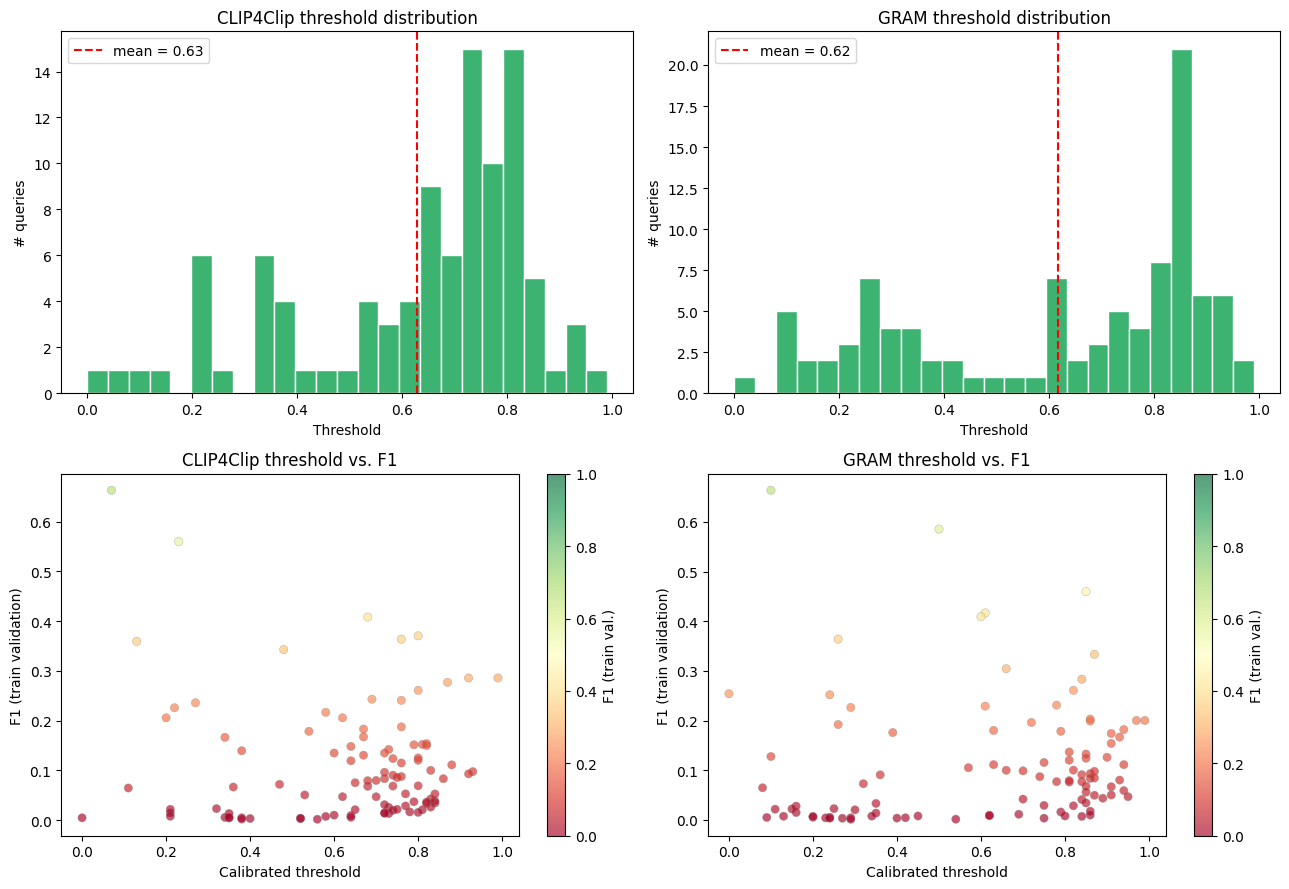

In [365]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col, (res_df, model_name) in enumerate([(clip_results, "CLIP4Clip"), (gram_results, "GRAM")]):
    thresholds = res_df["threshold"].values
    f1s        = res_df["f1"].values

    # Threshold distribution
    ax_hist = axes[0, col]
    ax_hist.hist(thresholds, bins=25, color="mediumseagreen", edgecolor="white")
    ax_hist.axvline(thresholds.mean(), color="red", linewidth=1.5, linestyle="--",
                    label=f"mean = {thresholds.mean():.2f}")
    ax_hist.set_title(f"{model_name} threshold distribution")
    ax_hist.set_xlabel("Threshold")
    ax_hist.set_ylabel("# queries")
    ax_hist.legend()

    # Threshold vs F1 scatter
    ax_scat = axes[1, col]
    sc = ax_scat.scatter(thresholds, f1s, c=f1s, cmap="RdYlGn", vmin=0, vmax=1,
                         alpha=0.65, edgecolors="grey", linewidths=0.3)
    plt.colorbar(sc, ax=ax_scat, label="F1 (train val.)")
    ax_scat.set_title(f"{model_name} threshold vs. F1")
    ax_scat.set_xlabel("Calibrated threshold")
    ax_scat.set_ylabel("F1 (train validation)")

plt.tight_layout()
plt.show()

## Per-Query Breakdown Table

In [366]:
clip_results

,iou,f1,ap,threshold,category
query,,,,,
An animal engaged in any activity other than foraging.,0.495783,0.662907,0.564280,0.07,RARE
An animal that is neither a red deer nor a roe deer.,0.033366,0.064577,0.016071,0.11,RARE
An animal running.,0.206897,0.342857,0.180393,0.48,RARE
An animal bathing.,0.227273,0.370370,0.091331,0.80,RARE
A roe deer grazing.,0.010526,0.020833,0.010967,0.81,RARE
...,...,...,...,...,...
"An animal foraging, then reacting to a camera, and then running away.",0.010989,0.021739,0.040388,0.75,CAMERA_REACTION
An animal reacting to a camera in rainy or overcast weather.,0.103448,0.187500,0.193150,0.76,CAMERA_REACTION
An animal reacting to a camera in clear or sunny weather.,0.074935,0.139423,0.079204,0.38,CAMERA_REACTION


In [367]:
# Merge per-query results from both models
merged = clip_results[["category", "threshold", "f1", "iou", "ap"]].copy()
merged = merged.rename(columns={"threshold": "thr_clip", "f1": "f1_clip", "iou": "iou_clip", "ap": "ap_clip"})

gram_cols = gram_results[["threshold", "f1", "iou", "ap"]].rename(
    columns={"threshold": "thr_gram", "f1": "f1_gram", "iou": "iou_gram", "ap": "ap_gram"}
)
# merged on index since query is the index of both dfs, and they have the same queries as index
merged = merged.merge(gram_cols,
    left_index=True, right_index=True, how="outer"
)

# Flag queries where the gap in F1 exceeds 0.1
merged["f1_diff"] = merged["f1_clip"] - merged["f1_gram"]
merged = merged.sort_values("f1_diff", ascending=False)

merged

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
query,,,,,,,,,,
An animal bathing.,RARE,0.80,0.370370,0.227273,0.091331,0.36,0.090566,0.047431,0.091331,0.279804
A red deer foraging in sunny weather.,SOCIAL,0.76,0.363636,0.222222,0.227715,0.75,0.115385,0.061224,0.227715,0.248252
An animal being vigilant while the weather is rainy or overcast.,SOCIAL,0.68,0.408046,0.256318,0.581542,0.26,0.191844,0.106099,0.581542,0.216202
An animal bathing while grooming.,RARE,0.80,0.260870,0.150000,0.077974,0.32,0.072727,0.037736,0.077974,0.188142
A juvenile roe deer.,RARE,0.82,0.153846,0.083333,NaN,0.80,0.007692,0.003861,NaN,0.146154
...,...,...,...,...,...,...,...,...,...,...
Two or more animals reacting to a camera.,CAMERA_REACTION,0.78,0.016529,0.008333,0.200000,0.93,0.166667,0.090909,0.200000,-0.150138
"An animal foraging, then reacting to a camera, and then running away.",CAMERA_REACTION,0.75,0.021739,0.010989,0.040388,0.99,0.200000,0.111111,0.040388,-0.178261
A video of an animal lying down while resting.,RARE,0.72,0.083333,0.043478,0.026916,0.60,0.409091,0.257143,0.026916,-0.325758


In [368]:
merged[merged["f1_clip"] < 0.1].sort_values("f1_clip", ascending=False).groupby("category").mean(numeric_only=True) # mean per category

,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
category,,,,,,,,,
CAMERA_REACTION,0.737000,0.053678,0.027825,0.072389,0.841000,0.088411,0.047285,0.072389,-0.034734
COMMON,0.470000,0.071979,0.037333,0.046458,0.700000,0.041667,0.021277,0.046458,0.030313
COURTSHIP,0.615455,0.027458,0.014080,0.057304,0.618182,0.055725,0.029641,0.057304,-0.028267
RARE,0.598462,0.033649,0.017260,0.018116,0.524231,0.080368,0.047715,0.018116,-0.046719
SOCIAL,0.594167,0.039114,0.020375,0.027766,0.553333,0.032989,0.017005,0.027766,0.006125


In [369]:
merged[merged['category']=="COMMON"]

,category,thr_clip,f1_clip,iou_clip,ap_clip,thr_gram,f1_gram,iou_gram,ap_gram,f1_diff
query,,,,,,,,,,
An empty video.,COMMON,0.47,0.071979,0.037333,0.046458,0.7,0.041667,0.021277,0.046458,0.030313
A single adult red deer foraging only.,COMMON,0.23,0.559668,0.388569,0.386829,0.5,0.585640,0.414067,0.386829,-0.025972


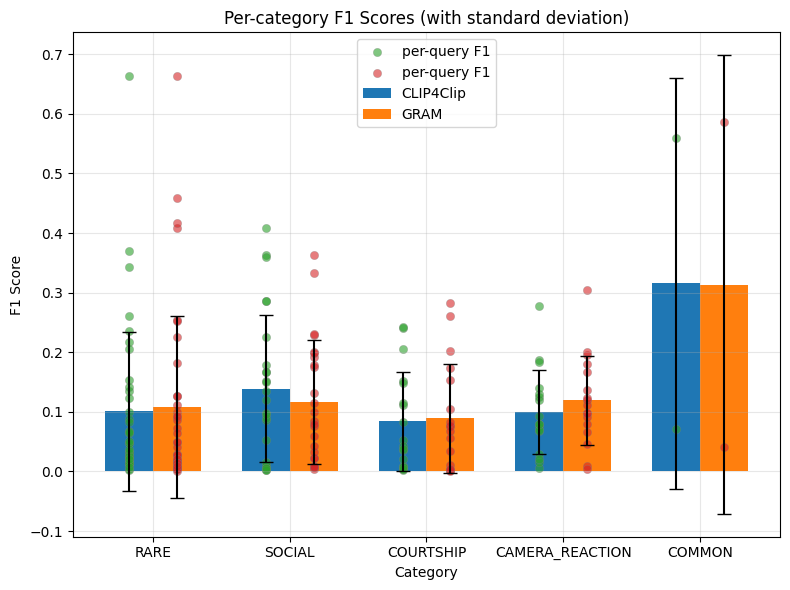

In [370]:
# barplot per category 2 barplots one for clip and one for gram, x axis category, y axis F1, error bars for stddev across queries in that category
categories = merged["category"].fillna("UNKNOWN").unique()
f1_clip_means = []
f1_gram_means = []
f1_clip_stds = []
f1_gram_stds = []

for cat in categories:
    subset = merged[merged["category"] == cat]
    f1_clip_means.append(subset["f1_clip"].mean())
    f1_gram_means.append(subset["f1_gram"].mean())
    f1_clip_stds.append(subset["f1_clip"].std())
    f1_gram_stds.append(subset["f1_gram"].std())

x_pos = range(len(categories))
width = 0.35

plt.figure(figsize=(8, 6))
bars_clip = plt.bar([x - width/2 for x in x_pos], f1_clip_means, width, label="CLIP4Clip", yerr=f1_clip_stds, capsize=5)
bars_gram = plt.bar([x + width/2 for x in x_pos], f1_gram_means, width, label="GRAM", yerr=f1_gram_stds, capsize=5)
scatter_clip_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] - width/2 for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_clip"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)

scatter_gram_per_query_per_category = plt.scatter(
    [x_pos[categories.tolist().index(cat)] + width/2 for cat in merged["category"].fillna("UNKNOWN")],
    merged["f1_gram"],
    alpha=0.6, edgecolors="grey", linewidths=0.3, label="per-query F1"
)
plt.xlabel("Category")
plt.ylabel("F1 Score")
plt.title("Per-category F1 Scores (with standard deviation)")
plt.xticks(x_pos, categories)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

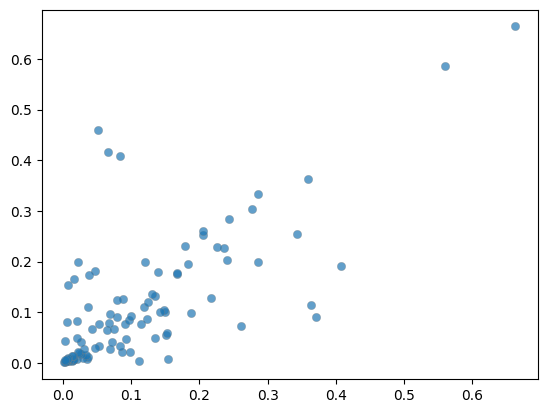

In [371]:
plt.scatter(merged["f1_clip"], merged["f1_gram"], alpha=0.7, edgecolors="grey", linewidths=0.3)

In [372]:
OUT_DIR = Path("results")
OUT_DIR.mkdir(exist_ok=True)

clip_results.to_csv(OUT_DIR / "clip4clip_test_per_query.csv", index=False)
gram_results.to_csv(OUT_DIR / "gram_test_per_query.csv", index=False)
merged.to_csv(OUT_DIR / "comparison_per_query.csv", index=False)

summary_df.to_csv(OUT_DIR / "summary_table.csv")

print("Saved:")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f}")

Saved:
  results/clip4clip_test_per_query.csv
  results/comparison_per_query.csv
  results/gram_test_per_query.csv
  results/summary_table.csv
